# Лабораторная работа №1  

# Статистические ряды распределения и нормальное распределение

**Цель работы:**  
Анализ возрастного распределения преступников в Москве (2021)
Провела статистический анализ данных с использованием Python. Построила дискретные и интервальные ряды распределения, рассчитала основные характеристики (среднее, медиана, дисперсия), визуализировала результаты и проверила гипотезу о нормальности распределения.

In [1]:
# Импорт библиотек
import matplotlib.pyplot as plt
import math

In [2]:
# Загрузка данных
with open("Москва_2021.txt", "r") as file:
    data = []
    for line in file:
        line = line.strip()
        if line != "":
            data.append(int(line))
n = len(data)

**Предварительный анализ данных**

Рассчитаем минимальное и максимальное значения, чтобы понять диапазон данных

In [3]:
min_val = min(data)
max_val = max(data)
print(f"Минимальное значение: {min_val}")
print(f"Максимальное значение: {max_val}")
print(f"Объем выборки: {n}")

Минимальное значение: 14
Максимальное значение: 73
Объем выборки: 32423


Данные охватывают возраст от 14 до 73 лет, с общим количеством наблюдений 32 423. Это позволяет построить дискретный и интервальный ряды распределения.

## Построение статистических рядов распределения

### 1.1. Дискретный ряд распределения

Дискретный ряд — это таблица, показывающая, сколько раз встречается каждое значение признака (в данном случае — возраст).  
Посчитаем частоты для каждого возраста.

In [4]:
frequency_dict = {}
for value in data:
    if value not in frequency_dict:
        frequency_dict[value] = 0
    frequency_dict[value] += 1

#### Построим полигон частот для дискретного ряда
Полигон частот используется для визуального представления формы распределения. Он показывает, как изменяются частоты значений признака ( возраста преступников). По форме полигона можно определить наличие моды, характер асимметрии и смещения распределения. В отличие от гистограммы, полигон наглядно демонстрирует динамику изменений между соседними значениями признака.

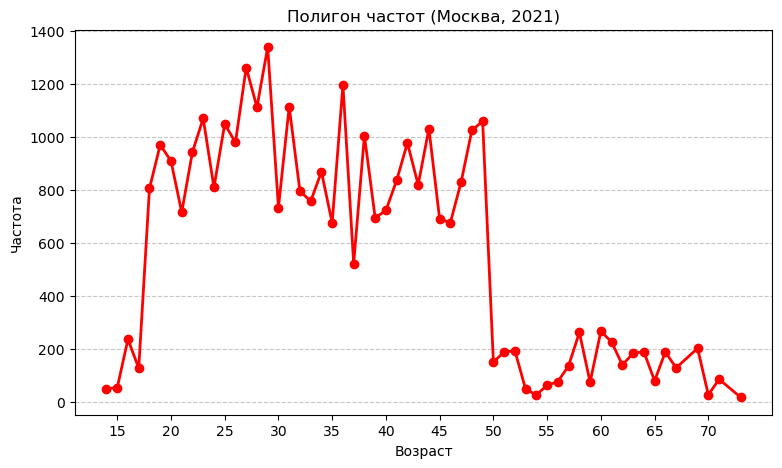

In [5]:
ages = sorted(frequency_dict.keys())
frequencies = [frequency_dict[age] for age in ages]
plt.figure(figsize=(9, 5))
plt.plot(ages, frequencies, marker="o", color="red", linewidth=2)
plt.xticks(range(min(ages)+1, max(ages) + 1, 5))
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.title("Полигон частот (Москва, 2021)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**Общая форма:** Полигон имеет выраженный асимметричный вид с правосторонним (положительным) смещением. Частоты возрастают с возраста 14 лет, достигают пика в диапазоне 20-30 лет, а затем постепенно снижаются, сохраняя некоторые колебания, до 73 лет.

**Колебания:** На графике видны заметные колебания частот в пределах диапазона 20-50 лет, что указывает на наличие нескольких локальных пиков. Это может быть связано с различными социальными или демографическими факторами.

Асимметрия и наличие длинного правого хвоста указывают на то, что распределение не является нормальным и имеет уклон в сторону более молодых возрастов.

#### Статистический анализ
Рассчитаем статистические характеристики для дискретного ряда.

In [6]:
def mean_calc(data):
    return sum(data) / len(data)

In [7]:
def variance_calc(data, mean_val):
    return sum((x - mean_val) ** 2 for x in data) / len(data)

In [8]:
def std_dev_calc(variance):
    return variance ** 0.5

In [9]:
def coeff_var_calc(std_dev, mean_val):
    return std_dev / mean_val *100

In [10]:
def mode_calc(freq_dict):
    max_freq = max(freq_dict.values())
    modes = [k for k, v in freq_dict.items() if v == max_freq]
    return modes, max_freq

In [11]:
def median_calc(data):
    sorted_data = sorted(data)
    n = len(sorted_data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        return (sorted_data[n // 2 - 1] + sorted_data[n // 2]) / 2

In [12]:
def range_calc(data):
    return max(data) - min(data)

In [13]:
print("Статистические характеристики дискретного ряда:")
print(f"Минимальное значение: {min_val}")
print(f"Максимальное значение: {max_val}")
print(f"Размах: {range_calc(data)}")
mean_val = mean_calc(data)
print(f"Средняя арифметическая: {mean_val:.2f}")
variance_val = variance_calc(data, mean_val)
print(f"Дисперсия: {variance_val:.2f}")
std_dev_val = std_dev_calc(variance_val)
print(f"Среднее квадратическое отклонение: {std_dev_val:.2f}")
print(f"Коэффициент вариации: {coeff_var_calc(std_dev_val, mean_val):.2f}%")
modes, mode_freq = mode_calc(frequency_dict)
print(f"Мода(ы): {modes} (частота: {mode_freq})")
print(f"Медиана: {median_calc(data)}")

Статистические характеристики дискретного ряда:
Минимальное значение: 14
Максимальное значение: 73
Размах: 59
Средняя арифметическая: 35.37
Дисперсия: 144.92
Среднее квадратическое отклонение: 12.04
Коэффициент вариации: 34.03%
Мода(ы): [29] (частота: 1340)
Медиана: 34


In [14]:
# Вычисление моментов, асимметрии и эксцесса
moment2 = sum((val - mean_val) ** 2 for val in data) / n
moment3 = sum((val - mean_val) ** 3 for val in data) / n
moment4 = sum((val - mean_val) ** 4 for val in data) / n
std_dev = moment2 ** 0.5
skewness = moment3 / (std_dev ** 3)
kurtosis = moment4 / (std_dev ** 4) - 3
print(f"Асимметрия: {skewness:.3f}")
print(f"Эксцесс: {kurtosis:.3f}")

# интерпретация асимметрии
if skewness > 0:
    print("Распределение имеет правосторонний скошенный хвост.")
elif skewness < 0:
    print("Распределение имеет левосторонний хвост.")
else:
    print("Распределение симметрично относительно среднего.")

# интерпретация эксцесса
if kurtosis > 0:
    print("Гистограмма более заострена по сравнению с нормальной.")
elif kurtosis < 0:
    print("Гистограмма более плоская по сравнению с нормальной.")
else:
    print("Распределение близко к нормальному.")

Асимметрия: 0.623
Эксцесс: -0.060
Распределение имеет правосторонний скошенный хвост.
Гистограмма более плоская по сравнению с нормальной.


**Вывод:** асимметрия положительная (0.623), что подтверждает правосторонний хвост. Эксцесс отрицательный (-0.060), указывая на более плоское распределение по сравнению с нормальным.

Проверим правило трех сигм.

In [15]:
# Функция для проверки трех сигм
def three_sigma_check(seq, mean_val, sigma_val):
    total = len(seq)
    bounds = [
        (mean_val - sigma_val, mean_val + sigma_val),
        (mean_val - 2 * sigma_val, mean_val + 2 * sigma_val),
        (mean_val - 3 * sigma_val, mean_val + 3 * sigma_val),
    ]

    result = []
    for idx, (lo, hi) in enumerate(bounds, 1):
        inside = sum(1 for el in seq if lo <= el <= hi)
        fraction = inside / total
        result.append((idx, inside, fraction))
    return result

Средний возраст преступников — 35 лет, с высокой вариацией (коэффициент 34.03%), что указывает на значительный разброс. Мода в 29 лет подтверждает пик в молодом возрасте.

Теперь рассчитаем асимметрию и эксцесс.

In [16]:
# Проверка
check = three_sigma_check(data, mean_val, std_dev)

print("\nПравило трёх сигм:")
reference = [0.683, 0.954, 0.997]
for (idx, cnt, frac), ref in zip(check, reference):
    print(f"{idx}σ: {frac * 100:.1f}% выборки (теоретически ≈ {ref * 100:.1f}%)")
    
# вывод по правилу трёх сигм
diff_list = [abs(frac - ref) for (_, _, frac), ref in zip(check, reference)]

print("\nЗаключение:")
if all(delta < 0.005 for delta in diff_list):
    print("правило трёх сигм подтверждается")
else:
    print("правило трёх сигм не подтверждается")


Правило трёх сигм:
1σ: 66.4% выборки (теоретически ≈ 68.3%)
2σ: 94.7% выборки (теоретически ≈ 95.4%)
3σ: 99.9% выборки (теоретически ≈ 99.7%)

Заключение:
правило трёх сигм не подтверждается


**Вывод:** отклонения от теоретических значений (например, 66.4% вместо 68.3% для 1σ) указывают на то, что распределение не нормальное.

#### Построим эмпирическую функцию распределения (ЭФР).
Эмпирическая функция распределения показывает, как накапливаются частоты по мере увеличения значения признака.

In [17]:
# накопленные частоты
sorted_ages = sorted(frequency_dict)
cum_sum = 0
cum_freq = []
for age in sorted_ages:
    cum_sum += frequency_dict[age]
    cum_freq.append(cum_sum)

# ЭФР (нормированные накопленные частоты)
empirical_f = [cf / n for cf in cum_freq]

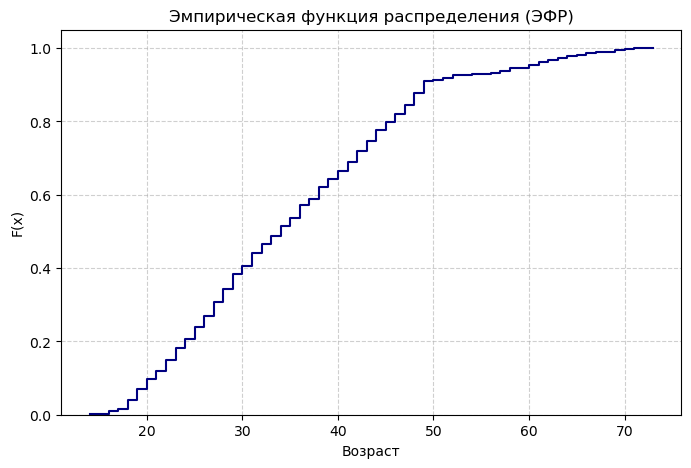

In [18]:
# построение графика
plt.figure(figsize=(8, 5))
plt.step(sorted_ages, empirical_f, where="post", color="navy")
plt.title("Эмпирическая функция распределения (ЭФР)")
plt.xlabel("Возраст")
plt.ylabel("F(x)")
plt.ylim(0, 1.05)
plt.grid(linestyle="--", alpha=0.6)
plt.show()


**Вывод по графику** 

График эмпирической функции распределения (ЭФР) показывает резкий рост кумулятивной вероятности в возрасте 18-36 лет, с пиком скачка при 29 лет, что отражает высокую концентрацию преступлений среди молодых людей. После 50 лет рост замедляется, достигая 100% только к 73 годам, указывая на редкость преступлений среди пожилых и подтверждая правостороннюю асимметрию распределения.

### Итоговые выводы анализа дискретного ряда распределения

- **Распределение возраста преступников**: Дискретный ряд (возраст от 14 до 73 лет) показывает пик частот в 29 лет (1340 случаев), с высокой концентрацией в диапазоне 20-40 лет (мода 29, медиана 34, среднее 35.37 из кода). Разброс значительный (размах 59, дисперсия 144.97, СКО 12.04, коэффициент вариации 34.03%), что подтверждается кодом расчёта характеристик и визуализацией полигона частот.

- **Асимметрия и эксцесс**: Положительная асимметрия (0.623) указывает на правосторонний хвост (длинный спад после 40 лет), а отрицательный эксцесс (-0.060) — на более плоское распределение по сравнению с нормальным, как рассчитано в коде через центральные моменты.

- **Нормальность распределения**: Правило трёх сигм не подтверждается (отклонения: 66.4% vs 68.3% для 1σ и т.д.), что видно из функции three_sigma_check в коде; распределение не нормальное, с дискретными скачками в ЭФР (быстрый рост до 50 лет, пологий хвост после).

- **Инсайты из данных и кода**: Преступления преимущественно совершают молодые люди (90% кумулятивной доли к 49 годам по ЭФР), с резким снижением после 40 лет; это может быть использовано для профилактики.

### 1.2. Интервальный ряд распределения (7 равных интервалов)

In [19]:
# Разделим диапазон на 7 интервалов
data_min = min(data)
data_max = max(data)
k=7
interval_width  = (max_val - min_val) / k
interval_width  = math.ceil(interval_width)  
intervals = [data_min + i * interval_width for i in range(k+1)]

In [20]:
# Подсчёт частот по интервалам
interval_frequency = [0] * k
for value in data:
    for i in range(k):
        if intervals[i] <= value < intervals[i + 1]:
            interval_frequency[i] += 1
            break

In [21]:
print("Интервальный ряд распределения:")
for i in range(k):
    print(f"{intervals[i]} - {intervals[i + 1]}: {interval_frequency[i]}")

Интервальный ряд распределения:
14 - 23: 4811
23 - 32: 9476
32 - 41: 7243
41 - 50: 7951
50 - 59: 1140
59 - 68: 1472
68 - 77: 330


#### Построим гистограмму частот для интервального ряда.
Гистограмма частот используется для визуального представления распределения данных, сгруппированных по интервалам. Она позволяет определить общую форму распределения, наличие асимметрии, выбросов и моду.
Поскольку данные сгруппированы, гистограмма показывает не отдельные значения, а диапазоны, что делает её особенно удобной при больших объёмах данных.

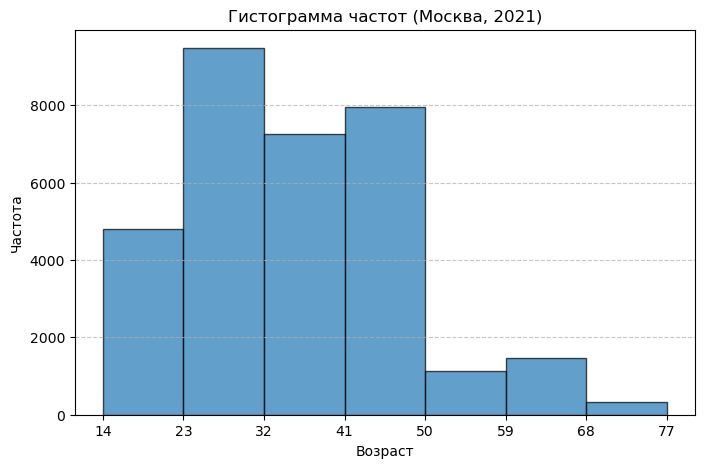

In [22]:

plt.figure(figsize=(8, 5))
plt.hist(data, bins=intervals, edgecolor="black", alpha=0.7)
plt.xlabel("Возраст")
plt.ylabel("Частота")
plt.title("Гистограмма частот (Москва, 2021)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(intervals)
plt.show()

Из гистограммы видно, что наибольшая частота приходится на интервал 23-32 лет (9476 случаев), за которым следует 41-50 лет (7951). Распределение имеет правосторонний уклон с длинным хвостом в старших возрастах (частоты после 50 лет резко падают: 1140 в 50-59, 1472 в 59-68, 330 в 68-77).

#### Статистический анализ
Рассчитаем статистические характеристики для интервального ряда.

In [23]:
# Середины интервалов
midpoints = [(intervals[i] + intervals[i + 1]) / 2 for i in range(k)]
total_freq = sum(interval_frequency)

In [24]:
# Среднее
mean_interval = sum(midpoints[i] * interval_frequency[i] for i in range(k)) / total_freq


In [25]:
# Дисперсия (несмещенная)
variance_interval = sum(
    interval_frequency[i] * (midpoints[i] - mean_interval) ** 2 for i in range(k)
) / (total_freq - 1)

In [26]:
# Среднее квадратическое отклонение
std_dev_interval = variance_interval ** 0.5

In [27]:
# Коэффициент вариации
var_coeff_interval = (std_dev_interval / mean_interval) * 100

In [28]:
# Мода для интервального ряда
max_freq_index = interval_frequency.index(max(interval_frequency))
modal_interval_index = max_freq_index
f_modal = interval_frequency[modal_interval_index]
f_prev = interval_frequency[modal_interval_index - 1] if modal_interval_index > 0 else 0
f_next = interval_frequency[modal_interval_index + 1] if modal_interval_index < k-1 else 0
L = intervals[modal_interval_index]
h = intervals[modal_interval_index + 1] - intervals[modal_interval_index]

mode_interval_value = L + ((f_modal - f_prev) / ((f_modal - f_prev) + (f_modal - f_next))) * h


In [29]:
# Медиана
cumulative_freq = [sum(interval_frequency[: i + 1]) for i in range(k)]
median_position = total_freq / 2
for i, cf in enumerate(cumulative_freq):
    if cf >= median_position:
        median_interval_index = i
        break
cf_prev = cumulative_freq[median_interval_index - 1] if median_interval_index > 0 else 0
L_median = intervals[median_interval_index]
h_median = intervals[median_interval_index + 1] - intervals[median_interval_index]
f_median = interval_frequency[median_interval_index]

median_interval_value = L_median + ((median_position - cf_prev) / f_median) * h_median


In [30]:
print("\nСтатистические характеристики интервального ряда:")
print(f"Среднее: {mean_interval:.5f}")
print(f"Дисперсия: {variance_interval:.5f}")
print(f"Среднее квадратическое отклонение: {std_dev_interval:.5f}")
print(f"Коэффициент вариации: {var_coeff_interval:.2f}%")
print(f"Мода: {mode_interval_value:.5f}, частота: {max(interval_frequency)}")
print(f"Медиана: {median_interval_value:.5f}")
print(f"Минимум: {intervals[0]}")
print(f"Максимум: {intervals[-1]}")
print(f"Размах: {intervals[-1] - intervals[0]}")


Статистические характеристики интервального ряда:
Среднее: 35.63089
Дисперсия: 148.54076
Среднее квадратическое отклонение: 12.18773
Коэффициент вариации: 34.21%
Мода: 29.08655, частота: 9476
Медиана: 34.39134
Минимум: 14
Максимум: 77
Размах: 63


Среднее значение (35 лет) и медиана (34 года) подтверждают концентрацию данных в молодом возрасте. Мода (29 лет) расположена в интервале 23-32 с максимальной частотой 9476, подчёркивая пик около 29 лет. Высокий коэффициент вариации (34.21%) указывает на значительный разброс данных, дисперсия 148.54076 и СКО 12.18773 подтверждают вариабельность.

### Итоговые выводы анализа интервального ряда распределения

- **Распределение возраста**: Интервальный ряд с 7 равными интервалами (от 14 до 77 лет) показывает наибольшую частоту в 23-32 лет (9476 случаев), с пиком моды 29 лет. Среднее (35 лет) и медиана (34 лет) подтверждают фокус на молодом возрасте, размах 63 лет отражает широкий диапазон.
- **Статистические характеристики**: Дисперсия (148.54076) и СКО (12.18773) указывают на значительную вариабельность, а коэффициент вариации (34.21%) подчёркивает неоднородность распределения.
- **Анализ формы**: Гистограмма и расчёты подтверждают правостороннюю асимметрию, с медленным спадом частот после 41-50 лет (7951 случаев), что согласуется с дискретным анализом.
- **Инсайты**: Преступления преимущественно совершаются людьми 20-40 лет, что может быть полезно для таргетирования профилактических мер. Интервальный подход сглаживает данные, но сохраняет ключевые паттерны дискретного ряда, подтверждая ненормальность распределения.